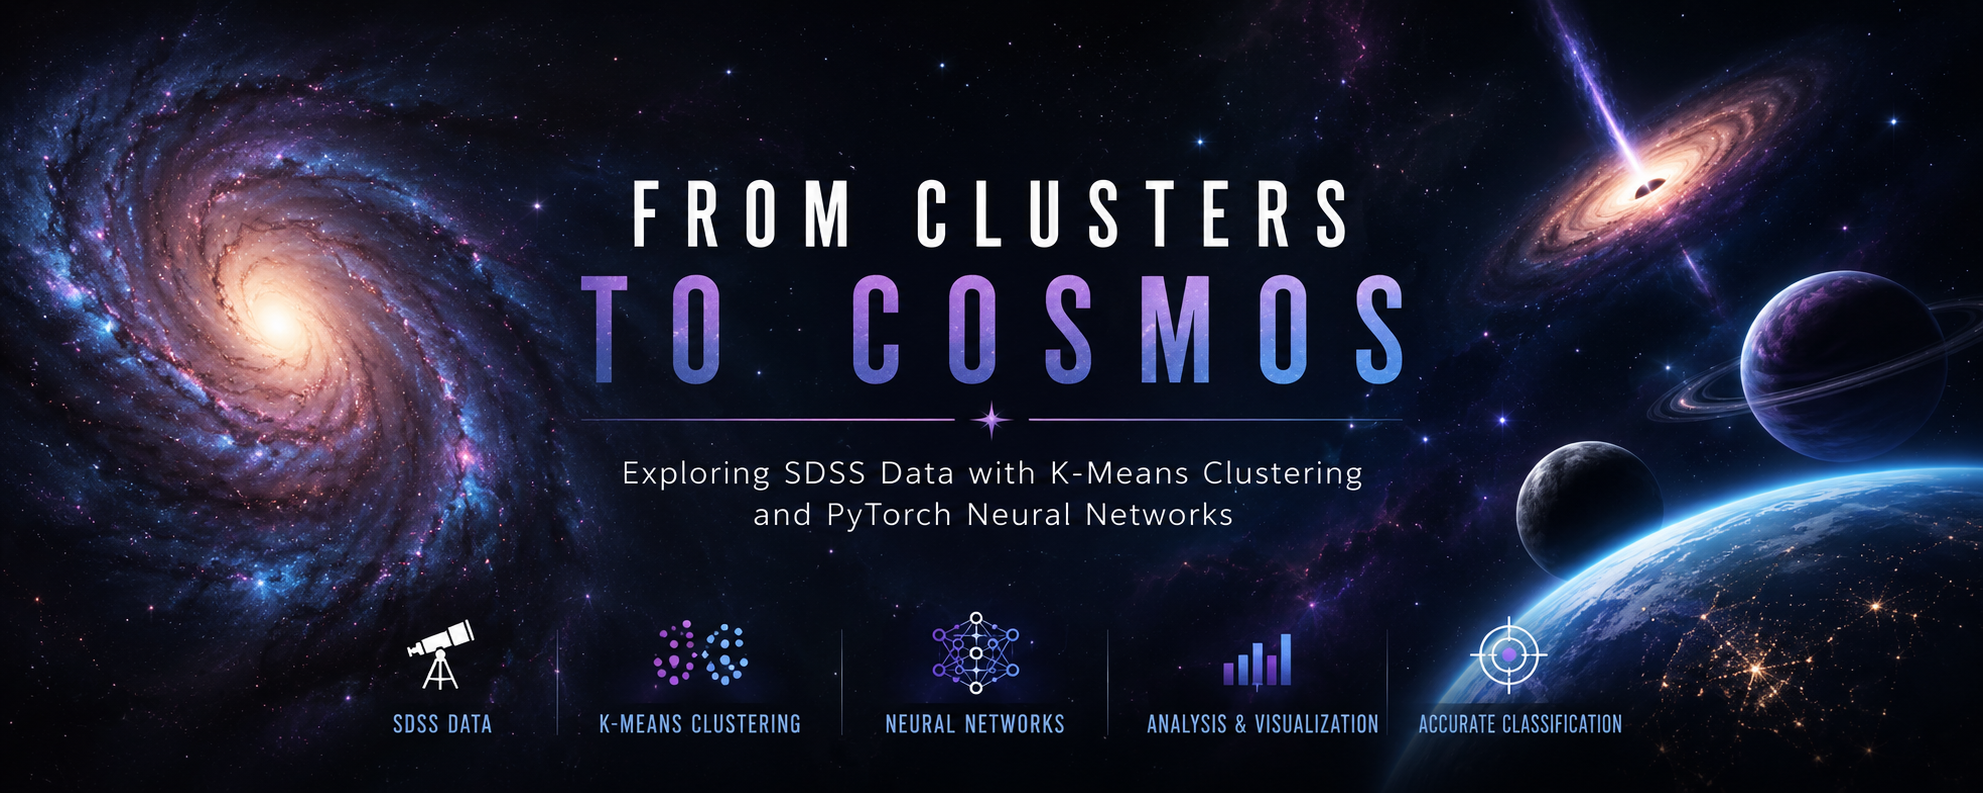

# Mapping the Cosmos: Exploring SDSS Data with K-Means Clustering and PyTorch Neural Networks

## Project Overview

This project develops a deep learning model to classify celestial objects into three categories: **Stars**, **Galaxies**, and **Quasars (QSOs)** using photometric observations from the Sloan Digital Sky Survey (SDSS).

The dataset consists of astronomical measurements captured in five optical bands (u, g, r, i, and z). In addition to the original features, astronomical color indices were engineered to improve class separability. A fully connected neural network was implemented using PyTorch to learn patterns from these features and accurately classify unseen objects.

The workflow includes:

- Data loading and preprocessing
- Exploratory Data Analysis (EDA)
- Data cleaning
- Feature engineering
- Feature scaling
- Neural network implementation using PyTorch
- Model training and evaluation
- Performance analysis

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- PyTorch
- Jupyter Notebook

### Dataset

- **Source:** Sloan Digital Sky Survey (SDSS)
- **Classes:** Galaxy, Star, QSO

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader , TensorDataset ,  random_split

In [ ]:
# ============================================================
# Install Required Libraries (Run only if needed)
# ============================================================

%pip install pandas numpy matplotlib seaborn plotly scikit-learn torch torchvision

# Getting hands over python pandas Dataframe and filter our columns, required for the project

In [2]:
df  = pd.read_csv("star_classification.csv")
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


# 🌌 Key Features Used in This Project

Although the SDSS dataset contains several observational and instrumental attributes, this project primarily focuses on the following astrophysical features, as they contain the most relevant information for classifying celestial objects.

| Feature | Description | Importance |
|---------|-------------|------------|
| **u** | Ultraviolet magnitude measured through the SDSS **u-band** filter (~355 nm). | Captures ultraviolet emission from celestial objects. |
| **g** | Green optical magnitude measured through the **g-band** filter (~475 nm). | Represents brightness in the blue-green region of the spectrum. |
| **r** | Red optical magnitude measured through the **r-band** filter (~622 nm). | Measures brightness in the red portion of visible light. |
| **i** | Near-infrared optical magnitude measured through the **i-band** filter (~763 nm). | Useful for observing cooler stars and distant galaxies. |
| **z** | Infrared magnitude measured through the **z-band** filter (~905 nm). | Captures longer wavelength emissions and highly redshifted objects. |
| **Redshift** | The displacement of light toward longer wavelengths due to the expansion of the universe. | Provides information about an object's distance and recessional velocity. |
| **Class** | Spectroscopic label assigned by SDSS. Possible values are **STAR**, **GALAXY**, and **QSO**. | Target variable used for supervised machine learning classification. |

## Why These Features?

The five photometric magnitudes (**u, g, r, i, z**) describe how bright an astronomical object appears at different wavelengths of light. Together, they form a unique spectral profile that helps distinguish between stars, galaxies, and quasars.

**Redshift** complements these measurements by providing physical information about the object's relative distance and motion, making it one of the most informative features for classification.

> **Note:** The astronomical magnitude scale is inverse, meaning **lower magnitude values indicate brighter objects**, while **higher values correspond to fainter objects**.

In [3]:
new_df = df[['u' , 'g' , 'r' , 'i' , 'z' , 'redshift' , 'class']]

new_df.head()


,u,g,r,i,z,redshift,class
0,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794,GALAXY
1,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136,GALAXY
2,25.26307,22.66389,20.60976,19.34857,18.94827,0.644195,GALAXY
3,22.13682,23.77656,21.61162,20.50454,19.25010,0.932346,GALAXY
4,19.43718,17.58028,16.49747,15.97711,15.54461,0.116123,GALAXY


In [4]:
engineered_features = pd.DataFrame({
    'u_g' : new_df['u']-new_df['g'],
    'g_r': new_df['g']-new_df['r'],
    'r_i': new_df['r']-new_df['i'],
    'i_z' :new_df['i']-new_df['z']
})


engineered_features.head()

,u_g,g_r,r_i,i_z
0,1.60352,1.88029,1.22928,0.37202
1,1.94571,0.24744,1.41632,-0.44615
2,2.59918,2.05413,1.26119,0.40030
3,-1.63974,2.16494,1.10708,1.25444
4,1.85690,1.08281,0.52036,0.43250


## 🔬 Feature Engineering: Color Indices

To improve the model's ability to distinguish between different celestial objects, four new features were created:

- **u_g = u − g**
- **g_r = g − r**
- **r_i = r − i**
- **i_z = i − z**

These **color indices** measure the difference in brightness between adjacent wavelength bands. Unlike raw magnitudes, they emphasize an object's spectral characteristics while reducing the effect of overall brightness, making them more effective for classifying **Stars**, **Galaxies**, and **QSOs**.

In [5]:
SDSS_data = pd.DataFrame({
    "u" : new_df['u'],
    "g" : new_df['g'],
    "r" : new_df['r'],
    "i" : new_df['i'],
    "z" : new_df['z'],
    "u_g": engineered_features['u_g'],
    "g_r": engineered_features['g_r'],
    "r_i":engineered_features['r_i'],
    "i_z":engineered_features['i_z'],
    "redshift":new_df['redshift'],
    "class":new_df['class'],
})

SDSS_data.head()

,u,g,r,i,z,u_g,g_r,r_i,i_z,redshift,class
0,23.87882,22.27530,20.39501,19.16573,18.79371,1.60352,1.88029,1.22928,0.37202,0.634794,GALAXY
1,24.77759,22.83188,22.58444,21.16812,21.61427,1.94571,0.24744,1.41632,-0.44615,0.779136,GALAXY
2,25.26307,22.66389,20.60976,19.34857,18.94827,2.59918,2.05413,1.26119,0.40030,0.644195,GALAXY
3,22.13682,23.77656,21.61162,20.50454,19.25010,-1.63974,2.16494,1.10708,1.25444,0.932346,GALAXY
4,19.43718,17.58028,16.49747,15.97711,15.54461,1.85690,1.08281,0.52036,0.43250,0.116123,GALAXY


# Preprocessing step: checking for empty NaN valuies in dataframe

In [6]:
empty_value_check = np.array([SDSS_data[col].isnull().sum() for col in SDSS_data if col != 'class'])
print(empty_value_check)

[0 0 0 0 0 0 0 0 0 0]


In [7]:
count_galaxies = len([count for count in SDSS_data['class'] if count =='GALAXY'])
count_qso = len([count for count in SDSS_data['class'] if count =='QSO'])
count_star = len([count for count in SDSS_data['class'] if count =='STAR'])

print(f"number of galaxies = {count_galaxies}")
print(f"number of quasi_steller_object = {count_qso}")
print(f"number of galaxies = {count_star}")

number of galaxies = 59445
number of quasi_steller_object = 18961
number of galaxies = 21594


# Filtering our random 600 rows from each class (galaxies , qso , stars) for teasing K-MEANS clustering algoritham over SDSS data

In [8]:
galaxies = []
stars = []
qso = []

for i in SDSS_data.index: #.index
    if(SDSS_data.loc[i,'class'] == 'GALAXY'):
        galaxies.append(SDSS_data.loc[i])#.iloc/loc
    elif(SDSS_data.loc[i,'class'] == 'QSO'):
        stars.append(SDSS_data.loc[i])
    elif(SDSS_data.loc[i,'class'] == 'STAR'):
        qso.append(SDSS_data.loc[i])

print(len(stars))


18961


In [9]:
import random
random.seed(242)

galaxies = random.sample(galaxies , 200)
stars = random.sample(stars , 200)
qso = random.sample(qso , 200)


sdss_list = galaxies + stars + qso

random.shuffle(sdss_list)

sdss_array = np.array(sdss_list)

sdss_array[1]


array([np.float64(17.63343), np.float64(16.57862), np.float64(16.57487),
       np.float64(16.6027), np.float64(16.67499),
       np.float64(1.0548099999999998), np.float64(0.003750000000000142),
       np.float64(-0.027829999999998023),
       np.float64(-0.07229000000000241), np.float64(-8.80265e-05), 'STAR'],
      dtype=object)

In [10]:
columns = [
    'u', 'g', 'r', 'i', 'z',
    'u_g', 'g_r', 'r_i', 'i_z',
    'redshift', 'class'
]

sampled_sdss = pd.DataFrame(sdss_array, columns=columns)

sampled_sdss.head()

,u,g,r,i,z,u_g,g_r,r_i,i_z,redshift,class
0,20.35039,18.18652,16.88648,16.36939,15.98839,2.16387,1.30004,0.51709,0.381,0.163822,GALAXY
1,17.63343,16.57862,16.57487,16.6027,16.67499,1.05481,0.00375,-0.02783,-0.07229,-0.000088,STAR
2,21.21091,20.22963,20.11371,20.13015,19.80049,0.98128,0.11592,-0.01644,0.32966,2.665428,QSO
3,20.56656,20.48502,20.43689,20.40608,20.35057,0.08154,0.04813,0.03081,0.05551,1.510443,QSO
4,21.03129,20.59398,20.50939,20.55706,20.20018,0.43731,0.08459,-0.04767,0.35688,2.477964,QSO


# Analyzing data for preprocessing step, to find any NaN and sentinel values

In [11]:
sampled_sdss.describe()


,u,g,r,i,z,u_g,g_r,r_i,i_z,redshift,class
count,600.00000,600.00000,600.00000,600.00000,600.00000,600.00000,600.00000,600.00000,600.00000,600.000000,600
unique,600.00000,600.00000,600.00000,600.00000,600.00000,599.00000,600.00000,600.00000,599.00000,600.000000,3
top,20.35039,18.18652,16.88648,16.36939,15.98839,1.49467,1.30004,0.51709,0.41621,0.163822,GALAXY
freq,1.00000,1.00000,1.00000,1.00000,1.00000,2.00000,1.00000,1.00000,2.00000,1.000000,200


In [12]:
max_each_feature = [float(sampled_sdss[c].max()) for c in sampled_sdss.columns if c!= 'class' ]

min_each_feature = [float(sampled_sdss[c].min()) for c in sampled_sdss.columns if c!='class']

print(max_each_feature)
print(min_each_feature)

[26.97862, 25.70713, 24.87046, 24.28568, 22.82691, 6.688880000000001, 5.00958, 3.6396000000000015, 5.356939999999998, 6.462293]
[16.52681, 14.80551, 13.99782, 13.62507, 13.36565, -2.5018199999999986, -2.7884899999999995, -4.180869999999999, -4.584860000000003, -0.002887673]


In [13]:
maxmingalaxy = sampled_sdss[sampled_sdss['class'] == 'GALAXY']
maxlistg = [float(np.max(maxmingalaxy[a].values)) for a in maxmingalaxy.columns if a!= 'class']
minlistg = [float(np.min(maxmingalaxy[a].values)) for a in maxmingalaxy.columns if a!= 'class']
print(maxlistg)
print(minlistg)



[26.97862, 25.70713, 23.54349, 22.62892, 22.82691, 6.688880000000001, 3.697230000000001, 1.7262999999999984, 1.0080100000000023, 1.404986]
[16.52681, 14.80551, 13.99782, 13.62507, 13.36565, -2.5018199999999986, 0.07168000000000063, -0.11745999999999768, -4.584860000000003, -0.0006027561]


In [14]:
maxminstar = sampled_sdss[sampled_sdss['class'] == 'STAR']
maxlists = [float(np.max(maxminstar[a].values)) for a in maxminstar.columns if a!= 'class']
minlists = [float(np.min(maxminstar[a].values)) for a in maxminstar.columns if a!= 'class']
print(maxlists)
print(minlists)

[26.57273, 25.5549, 24.87046, 24.28568, 22.80751, 4.537500000000001, 5.00958, 3.6396000000000015, 5.356939999999998, 0.002404557]
[16.88986, 15.33756, 14.74232, 14.52093, 14.4619, -0.8518100000000004, -2.7884899999999995, -4.180869999999999, -1.5595999999999997, -0.002887673]


In [15]:
maxminqso = sampled_sdss[sampled_sdss['class'] == 'QSO']
maxlistq = [float(np.max(maxminqso[a].values)) for a in maxminqso.columns if a!= 'class']
minlistq = [float(np.min(maxminqso[a].values)) for a in maxminqso.columns if a!= 'class']
print(maxlistq)
print(minlistq)

[26.43719, 25.11437, 23.18634, 22.19963, 22.49928, 4.3959399999999995, 3.6167499999999997, 2.04336, 1.1252500000000012, 6.462293]
[17.90187, 17.14422, 16.45493, 16.05408, 15.83081, -1.5749499999999976, -0.2985199999999999, -0.3287399999999998, -0.8490199999999994, 0.1408577]


## 📊 Pairwise Feature Visualization

A **pair plot** was generated to explore the relationships between the selected features before applying clustering.

By visualizing every pair of features simultaneously, it becomes easier to identify **natural groupings**, **correlations**, **overlapping regions**, and **potential outliers**. These observations help determine whether the data exhibits patterns that can be effectively separated using clustering algorithms such as **K-Means**.

The diagonal plots show the distribution of each feature individually, while the off-diagonal plots reveal how pairs of features interact across different object classes.

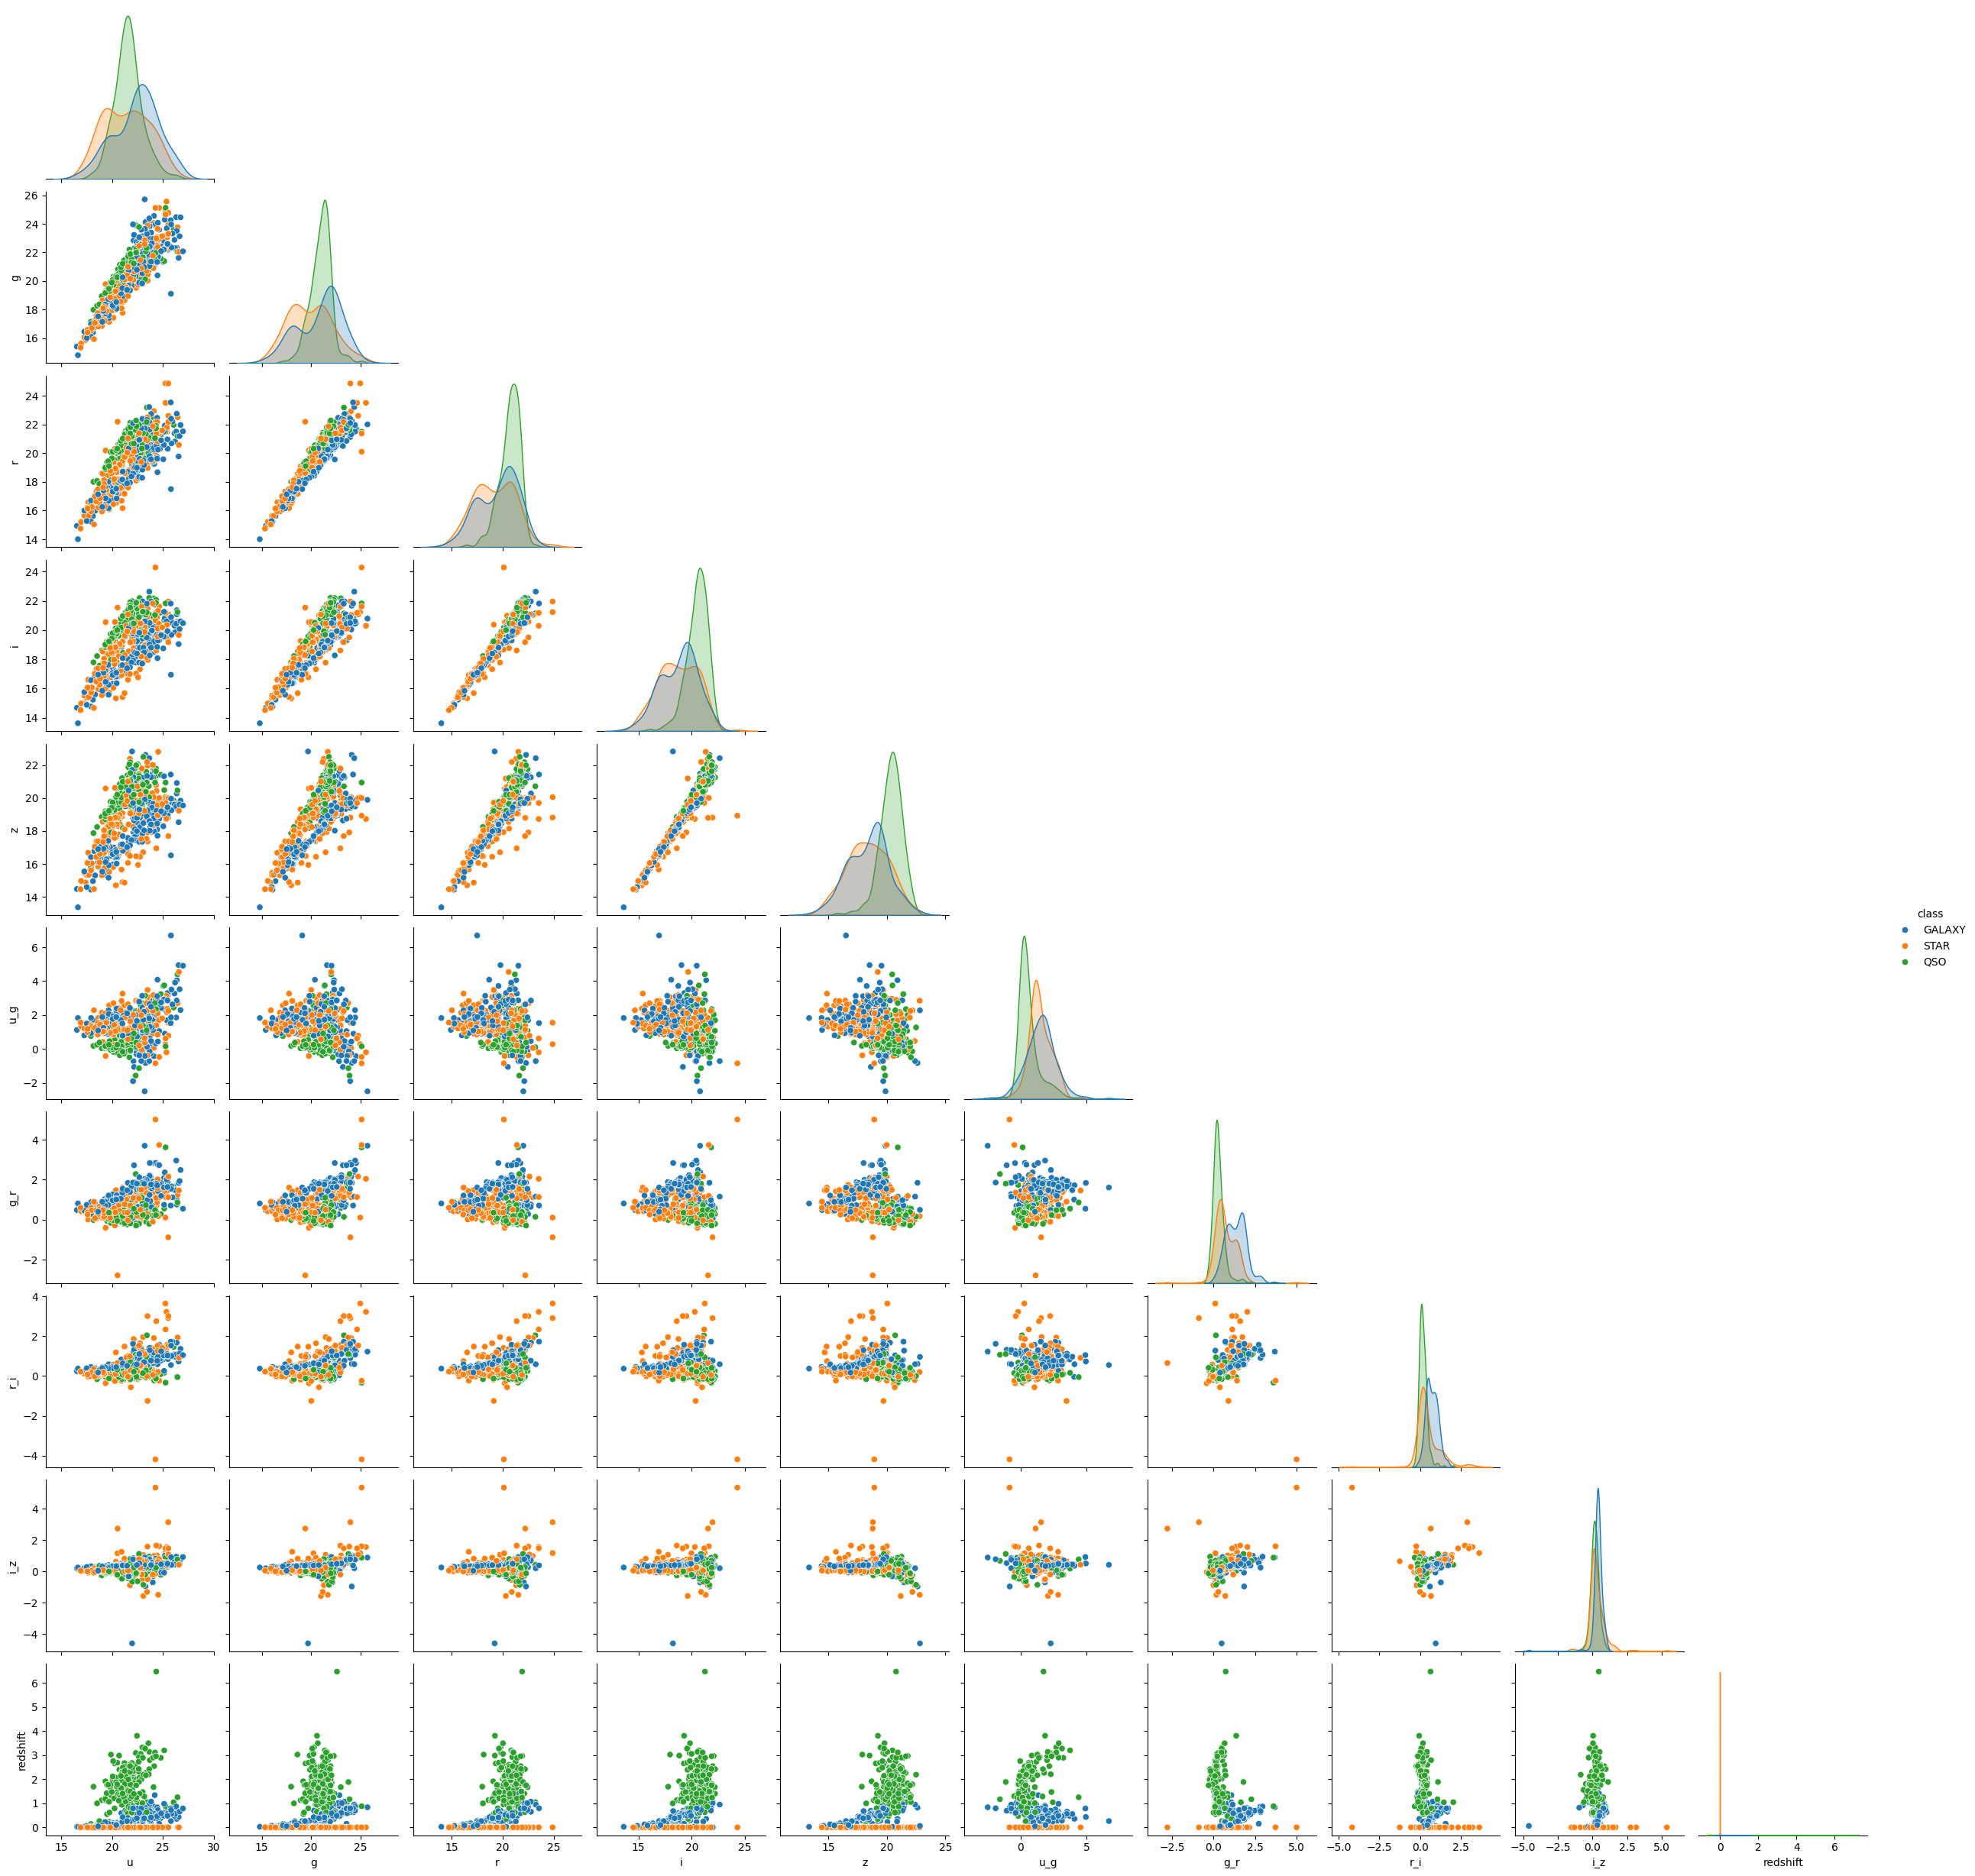

In [16]:
sns.pairplot(
    sampled_sdss,
    vars=['u', 'g', 'r', 'i', 'z',
    'u_g', 'g_r', 'r_i', 'i_z',
    'redshift'],
    hue='class',
    corner=True
)
plt.show()

# 📌 Observations

The pair plot revealed that the **redshift** feature exhibited a noticeably different distribution compared to the photometric features (**u, g, r, i, z**). While many feature pairs showed overlapping patterns, plots involving **redshift** displayed better separation among the object classes.

This suggests that **redshift** is a highly informative feature for distinguishing between **Stars**, **Galaxies**, and **QSOs**, and is likely to play a significant role in both clustering and classification tasks.

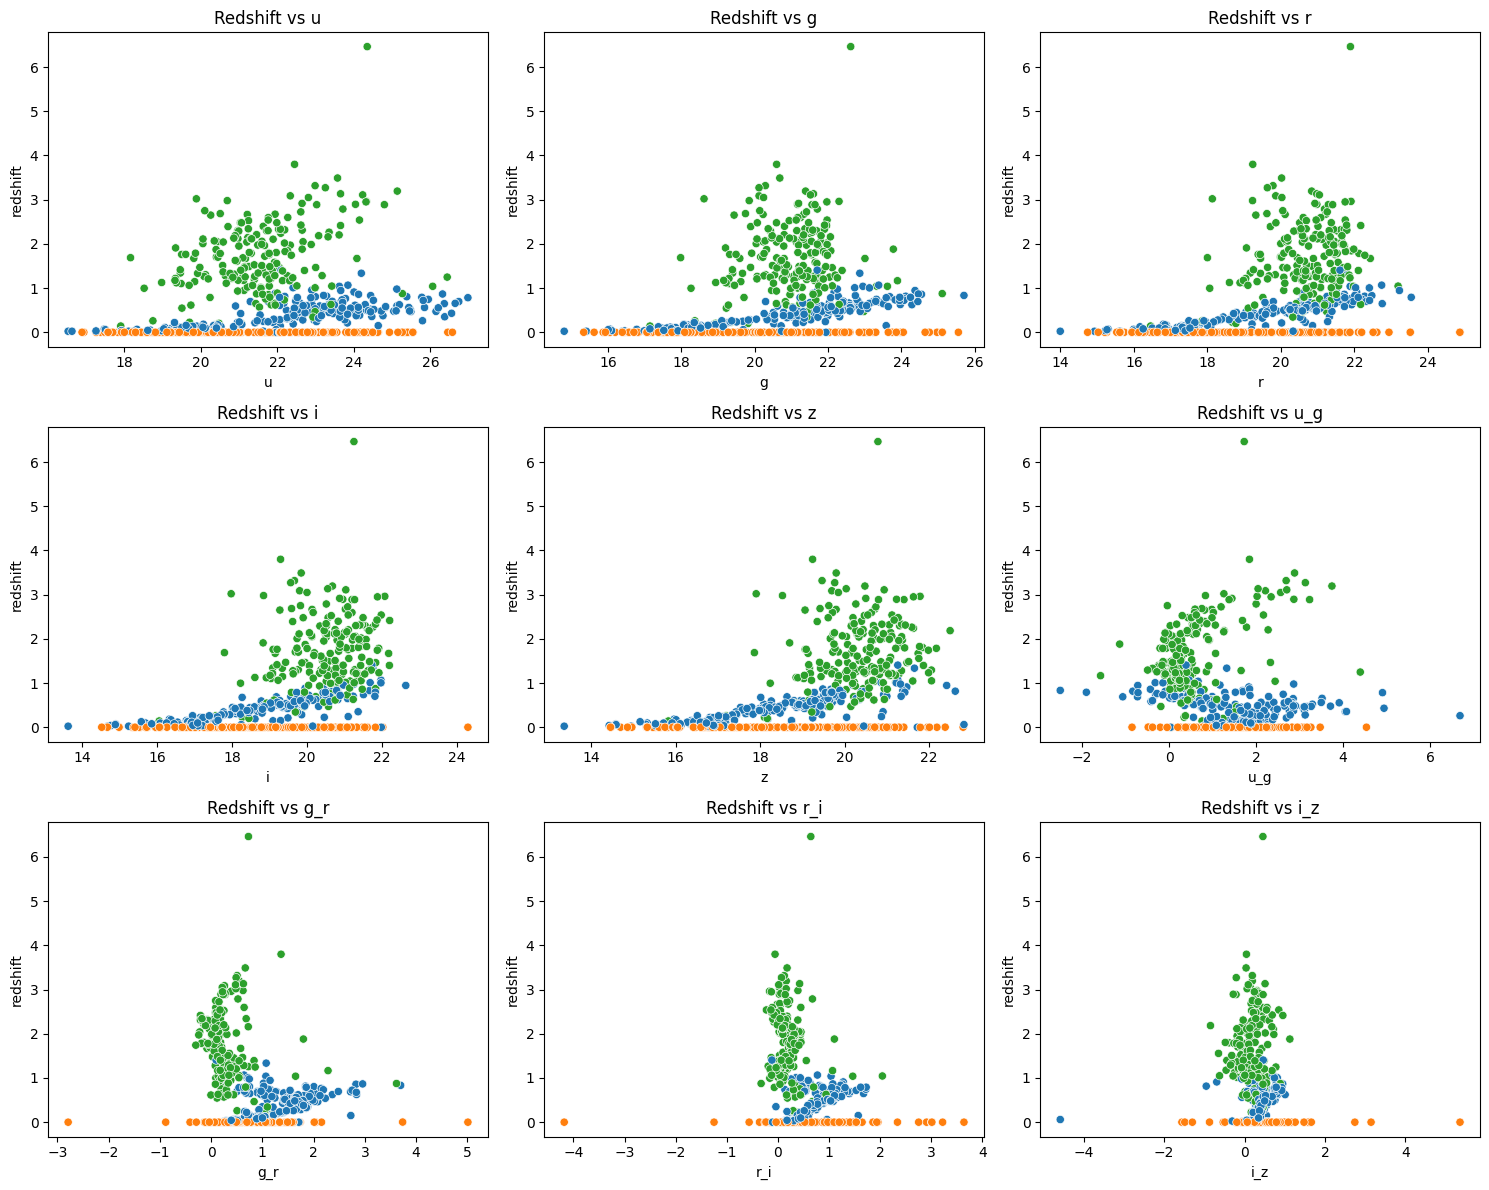

In [17]:
#best relationship yet is shown by redshift

features = [
    'u','g','r','i','z','u_g' , 'g_r' , 'r_i' , 'i_z'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.flat, features):
    sns.scatterplot(
        data=sampled_sdss,
        x=feature,
        y='redshift',
        hue='class',
        ax=ax,
        legend=False
    )
    ax.set_title(f'Redshift vs {feature}')

plt.tight_layout()
plt.show()

## 📌 Observations

- Scatter plots with **redshift** on one of the axes showed noticeable separation between the three object classes, indicating that **redshift** is a highly informative feature.
- Despite this separation, a significant amount of **overlap (superposition)** still existed between the clusters, suggesting that a single feature is insufficient for complete separation.
- Among the engineered color indices, **g_r** exhibited the clearest grouping and the least overlap, making it the strongest candidate for clustering and subsequent analysis.

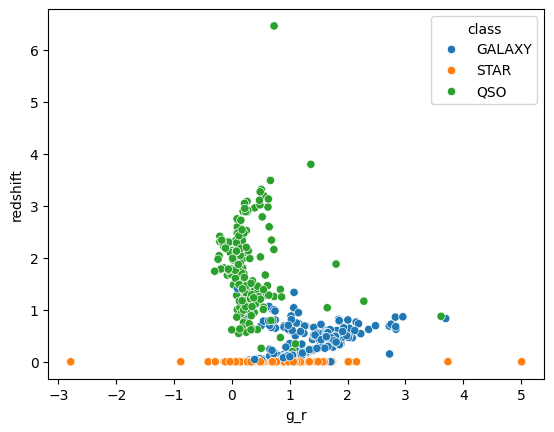

In [18]:
# redshift vs ug seems to be the best candidate for using k means

k_means_sampled = sampled_sdss[['g_r' , 'redshift' , 'class' , 'i_z']]

sns.scatterplot(
    data=k_means_sampled,
    x='g_r',
    y='redshift',
    hue='class'
)

plt.show()


Although **redshift** provided noticeable separation, there was still considerable **superposition between the QSO and GALAXY classes**, indicating that these objects cannot be completely distinguished using a single feature.

This observation suggests that **combining multiple informative features**, such as **redshift** with the engineered color indices (particularly **g_r**), may provide better class separation and improve clustering performance.

In [19]:
import plotly.express as px
import nbformat

fig = px.scatter_3d(
    k_means_sampled,
    x='g_r',
    y='i_z',
    z='redshift',
    color='class'
)

fig.update_traces(marker=dict(size=2))

fig.show()

## 🌐 3D Interactive Visualization

While the pair plots provided useful insights, they were limited to two-dimensional feature relationships. To better understand the overall data distribution, an **interactive 3D scatter plot** was created.

In the 3D visualization, the three classes (**STAR**, **GALAXY**, and **QSO**) formed more distinguishable clusters, making their spatial relationships easier to observe. Although some overlap between **GALAXY** and **QSO** remained, the interactive plot offered a much clearer representation of the underlying cluster structure than the 2D visualizations.

In [20]:
from sklearn.cluster import KMeans

KMeans_SDSS_data = sampled_sdss[['g_r' , 'i_z', 'redshift']]

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters = i , init = 'k-means++' , max_iter = 500 , n_init =10 , random_state=0)
    kmeans.fit(KMeans_SDSS_data)
    wcss.append(kmeans.inertia_)


## 📈 Selecting the Optimal Number of Clusters: Elbow Method

Before applying **K-Means clustering**, the **Elbow Method** was used to determine the optimal number of clusters (`k`).

The method computes the **Within-Cluster Sum of Squares (WCSS)** for different values of `k`. As the number of clusters increases, WCSS decreases. The optimal value is identified at the **"elbow"** of the curve, where the rate of decrease begins to level off.

For this dataset, the elbow occurred at **k = 3**, indicating that three clusters best represent the underlying data structure, which also aligns with the three known object classes: **STAR**, **GALAXY**, and **QSO**.

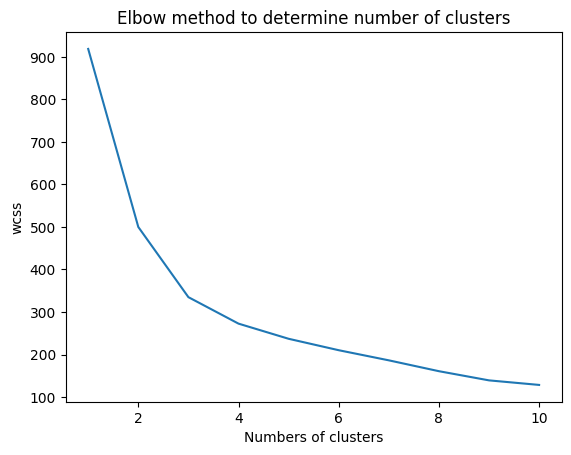

In [21]:
plt.plot(range(1,11),wcss)
plt.xlabel('Numbers of clusters')
plt.ylabel('wcss')
plt.title('Elbow method to determine number of clusters')
plt.show()

## 🎯 K-Means Clustering Results

After selecting **k = 3**, the K-Means algorithm was applied to the dataset. The algorithm iteratively assigned each data point to its nearest centroid and updated the centroid positions until convergence.

The resulting centroids represent the centers of the three discovered clusters. Visualizing these centroids alongside the clustered data provides a clear understanding of how K-Means partitions the feature space and highlights the natural grouping of **Stars**, **Galaxies**, and **QSOs**.

In [22]:
kmeans = KMeans(n_clusters = 3 , init = 'k-means++' , max_iter = 300 ,n_init = 10 , random_state = 0 )
ymeans = kmeans.fit_predict(KMeans_SDSS_data)
clusters = kmeans.cluster_centers_
print(clusters)

[[0.23228994 0.12652835 1.93557995]
 [0.50502454 0.16751108 0.17948454]
 [1.68405259 0.58559124 0.35645343]]


In [23]:
centers = kmeans.cluster_centers_

fig = px.scatter_3d(
    k_means_sampled,
    x='g_r',
    y='i_z',
    z='redshift',
    color='class',
    
)

fig.add_scatter3d(
    x=clusters[:, 0],
    y=clusters[:, 1],
    z=clusters[:, 2],
    mode='markers',
    marker=dict(size=10, color='black', symbol='diamond'),
    name='Centroids',
    
)

fig.update_traces(marker=dict(size=2))

fig.show()

## Understanding K-Means Clustering

K-Means is an **unsupervised machine learning algorithm** that groups similar data points into a predefined number of clusters. Unlike classification, it does **not use the class labels** during training. Instead, it discovers patterns based solely on the similarity between feature values.

After running the algorithm, K-Means provides:

- **Cluster assignments** indicating which cluster each data point belongs to.
- **Cluster centroids**, which represent the center of each cluster.
- **Inertia (WCSS)**, a measure of how compact the clusters are.
- A visualization of the underlying data structure, helping determine whether natural groups exist within the dataset.

By comparing the discovered clusters with the true labels (**STAR**, **GALAXY**, and **QSO**), we can evaluate how well the natural structure of the data aligns with the known astronomical classes.

## 🤖 K-Means Clustering

K-Means clustering was applied to group similar astronomical objects based solely on their feature values. Since it is an **unsupervised learning algorithm**, no class labels (**STAR**, **GALAXY**, or **QSO**) were provided during clustering.

The algorithm partitions the dataset into **k = 3** clusters by iteratively assigning each data point to its nearest centroid and updating the centroid positions until they stabilize.

Running K-Means provides valuable insights, including:

- The cluster assignment for every data point.
- The centroid (center) of each cluster.
- The compactness of the clusters through the **Within-Cluster Sum of Squares (WCSS)**.
- An understanding of the natural grouping present in the dataset.

These results help determine whether the underlying structure of the data naturally corresponds to the known astronomical object classes.

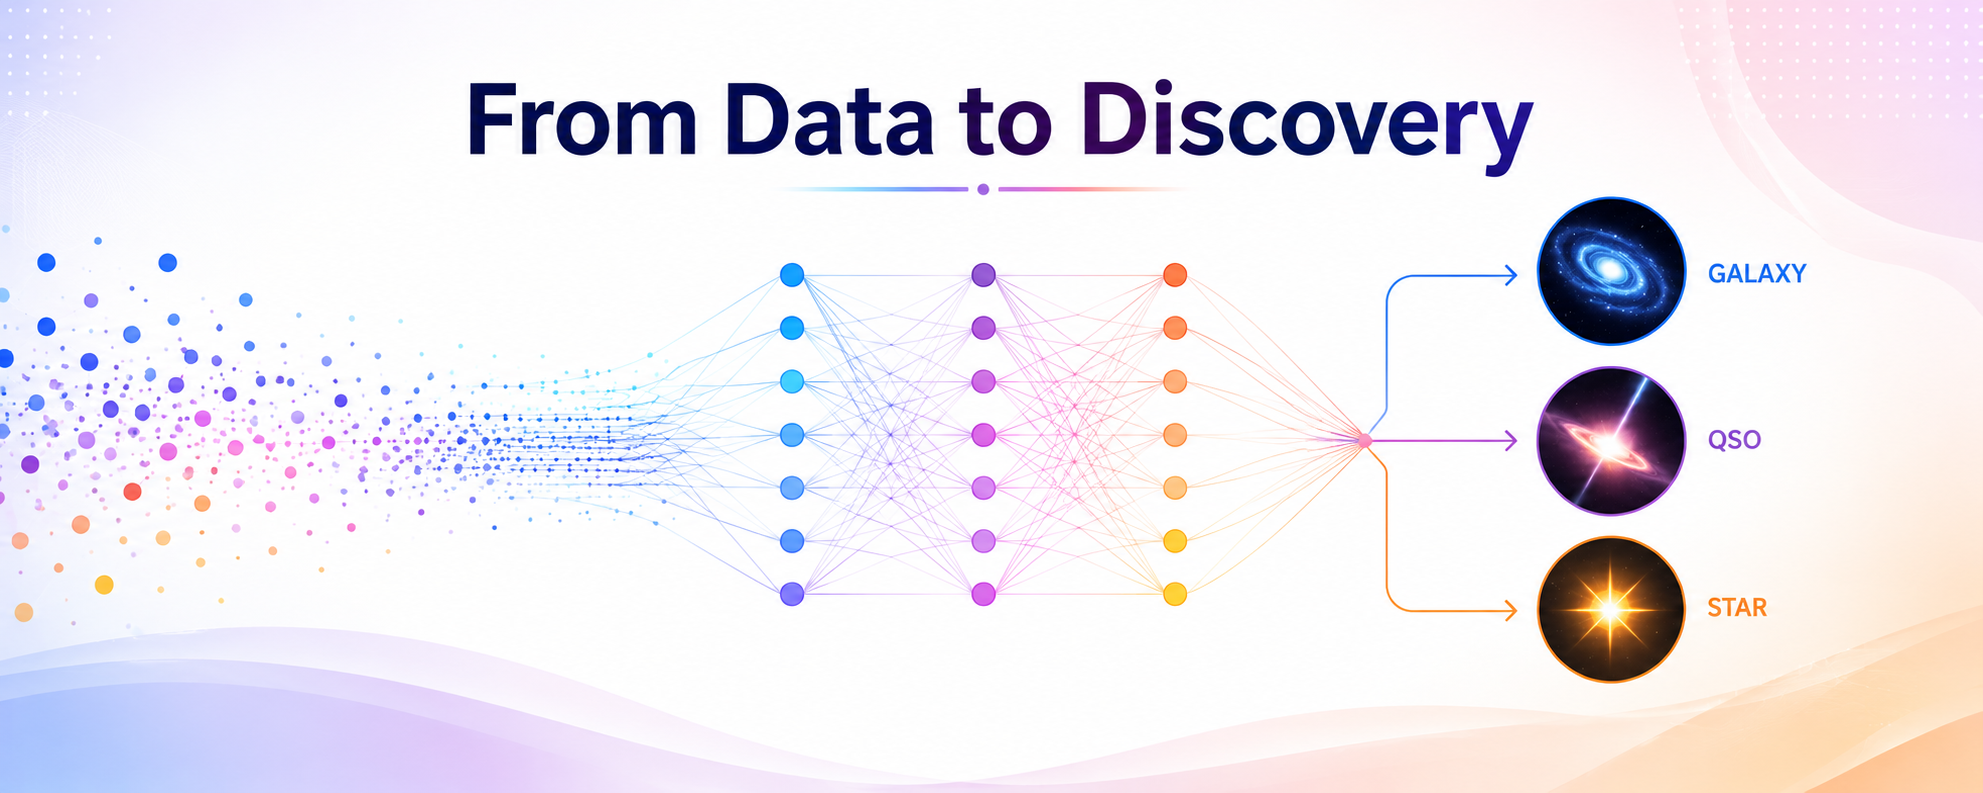

# 🧠 Neural Network Classification

Unlike K-Means, which groups data without using labels, a **Neural Network** is a **supervised learning algorithm** that learns from labeled examples to classify astronomical objects.

The network receives the selected features as input, processes them through multiple hidden layers, and learns complex, non-linear relationships between the features. During training, the model adjusts its weights using **backpropagation** and an optimization algorithm to minimize the classification error.

For this project, the neural network was trained to classify each observation into one of three classes:

- 🌟 **STAR**
- 🌌 **GALAXY**
- ✨ **QSO (Quasi-Stellar Object)**

After training, the model predicts the probability of each class for unseen data, with the class having the highest probability selected as the final prediction. This approach enables the model to capture intricate feature interactions and achieve high classification accuracy.

In [24]:
SDSS_data.head()

,u,g,r,i,z,u_g,g_r,r_i,i_z,redshift,class
0,23.87882,22.27530,20.39501,19.16573,18.79371,1.60352,1.88029,1.22928,0.37202,0.634794,GALAXY
1,24.77759,22.83188,22.58444,21.16812,21.61427,1.94571,0.24744,1.41632,-0.44615,0.779136,GALAXY
2,25.26307,22.66389,20.60976,19.34857,18.94827,2.59918,2.05413,1.26119,0.40030,0.644195,GALAXY
3,22.13682,23.77656,21.61162,20.50454,19.25010,-1.63974,2.16494,1.10708,1.25444,0.932346,GALAXY
4,19.43718,17.58028,16.49747,15.97711,15.54461,1.85690,1.08281,0.52036,0.43250,0.116123,GALAXY


# preprocessing orignal sdss data for NaN and sentinel values

In [25]:
minvalue = [float(SDSS_data[col].min()) for col  in SDSS_data.columns if col != 'class']
maxvalue = [float(SDSS_data[col].max()) for col  in SDSS_data.columns if col != 'class']
print(minvalue)
print(maxvalue)

[-9999.0, -9999.0, 9.82207, 9.469903, -9999.0, -12.74814, -10017.1656, -14.649069999999998, -13.162489999999998, -0.009970667]
[32.78139, 31.60224, 29.57186, 32.14147, 29.38374, 18.624950000000002, 14.315169999999998, 12.205799999999998, 10017.01675, 7.011245]



During the initial exploratory analysis, the summary statistics revealed unusually low minimum values (e.g., **-9999**) in several features. Since these values fall far outside the valid range of astronomical measurements, they were identified as **sentinel values**, which are placeholders used to represent missing or invalid observations rather than actual data.

These sentinel values were removed during preprocessing to ensure the quality and reliability of the dataset before further analysis and model training.

In [26]:
sentinel_value_positive = [(SDSS_data[col] > 35).sum() for col in SDSS_data.columns if col != 'class']
print(sentinel_value_positive)

[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]


In [27]:
sentinel_value_negative = [(SDSS_data[col] <-15).sum() for col in SDSS_data.columns if col != 'class']
print(sentinel_value_negative)

[np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0)]


## Handling Sentinel Values

Instead of removing the affected observations, the identified **sentinel values** were handled using **value clipping**. All feature values were constrained to a valid range by setting:

- **Minimum value:** `-15`
- **Maximum value:** `35`

Any value below **-15** was replaced with **-15**, while values above **35** were replaced with **35**. This approach limits the influence of extreme or invalid observations while preserving the overall size and distribution of the dataset for subsequent analysis and model training.

In [28]:
for col in SDSS_data.columns:
    if col != 'class':
        SDSS_data.loc[SDSS_data[col] > 35, col] = 25
        SDSS_data.loc[SDSS_data[col] < -15 , col] = 0

## CUDA Acceleration

To speed up training, this project uses **CUDA**, NVIDIA's GPU computing framework. Instead of performing all computations on the CPU, CUDA allows PyTorch to utilize the GPU, making matrix operations and neural network training significantly faster.

If a CUDA-enabled GPU is available, the model automatically runs on the GPU; otherwise, it falls back to the CPU.

In [29]:
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

True
cuda


## Building the Neural Network

A custom neural network was built using **PyTorch** by creating a class that inherits from `nn.Module`. The architecture consists of multiple fully connected layers with **ReLU** activation functions, followed by an output layer for three-class classification (**STAR**, **GALAXY**, and **QSO**). This modular design makes the model easy to train, evaluate, and modify.

In [43]:
class linearforward(nn.Module):
    def __init__(self , optimizer):
        super().__init__()
        self.model = nn.Sequential(nn.Linear(10,64), nn.ReLU() , nn.Linear(64,32) , nn.ReLU() , nn.Linear(32,10) , nn.ReLU() , nn.Linear(10,3))
        self.optimizer = optimizer
        


    def forward(self, x):
        x = x.to(device)
        output = self.model(x)
        return output
        
    def train_model(self ,dataloader , loss_function , epochs):
        self.to(device)
        self.train()
        
        for epoch in range(epochs):

            running_loss = 0
            correct = 0
            total = 0
            
            for x , y in dataloader:
                self.optimizer.zero_grad()

                x = x.to(device)
                y = y.to(device)

                output = self(x)
                loss = loss_function(output ,y)

                loss.backward()
                self.optimizer.step()

                running_loss += loss.item()
                _ , predicted = torch.max(output , 1)
                total += y.size(0)
                correct += (predicted==y).sum().item()
                epoch_loss = running_loss/len(dataloader)
                epoch_accuracy  = 100*correct/total

                print(
                    f"Epoch[{epoch+1}/epochs]"
                    f"Loss:{epoch_loss:.4f}"
                    f"Accuracy:{epoch_accuracy:.2f}%"
                )


    def evaluate(self, dataloader , loss_function):
        self.eval()
        running_loss = 0
        correct = 0
        total = 0 

        with torch.no_grad():

            for x ,y in dataloader:
                x = x.to(device)
                y = y.to(device)

                output = self(x)

                loss = loss_function(output , y)
                running_loss += loss.item()
                _ , predicted = torch.max(output,1)

                total += y.size(0)
                correct += (predicted == y).sum().item()


            test_loss = running_loss/len(dataloader)
            test_accuracy = 100 *correct/total
            self.train()

            return test_loss , test_accuracy






In [33]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()


sdsstrainy = SDSS_data['class'].values
sdsstrainx = SDSS_data.drop(columns=["class"]).values
sdsstrainy = encoder.fit_transform(sdsstrainy)

x = torch.tensor(sdsstrainx , dtype = torch.float32)
y  = torch.tensor(sdsstrainy , dtype = torch.long)

dataset = TensorDataset(x,y)

train_size = int(0.8*len(dataset))
test_size = len(dataset) - train_size

train_dataset , test_dataset = random_split(dataset , [train_size , test_size])


train_loader = DataLoader(train_dataset , batch_size = 100 , shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64 , shuffle = False)


for features , labels in train_loader:
    print(features.shape)
    print(labels.shape)
    break

torch.Size([100, 10])
torch.Size([100])


## Training the Model

To train the neural network, the dataset was divided into training and testing sets. During each epoch, the model performed a forward pass to generate predictions, computed the loss using the chosen loss function, and updated its weights through **backpropagation** and the **optimizer**. This process was repeated until the model learned to accurately classify **STAR**, **GALAXY**, and **QSO** objects.

In [47]:
train = linearforward(optimizer = None)
optimizer = torch.optim.Adam(train.parameters() , lr = 0.001)
train.optimizer = optimizer
loss_function = nn.CrossEntropyLoss()


train.train_model(train_loader , loss_function , 50)
test_loss, test_accuracy = train.evaluate(test_loader, loss_function)

print('\n')

print(f'Accuracy on test set = {test_accuracy}')


Epoch[1/epochs]Loss:0.0014Accuracy:60.00%
Epoch[1/epochs]Loss:0.0027Accuracy:61.00%
Epoch[1/epochs]Loss:0.0040Accuracy:58.67%
Epoch[1/epochs]Loss:0.0053Accuracy:60.50%
Epoch[1/epochs]Loss:0.0066Accuracy:58.80%
Epoch[1/epochs]Loss:0.0079Accuracy:59.17%
Epoch[1/epochs]Loss:0.0092Accuracy:60.14%
Epoch[1/epochs]Loss:0.0104Accuracy:61.12%
Epoch[1/epochs]Loss:0.0117Accuracy:61.44%
Epoch[1/epochs]Loss:0.0129Accuracy:61.40%
Epoch[1/epochs]Loss:0.0141Accuracy:61.18%
Epoch[1/epochs]Loss:0.0154Accuracy:61.25%
Epoch[1/epochs]Loss:0.0167Accuracy:60.62%
Epoch[1/epochs]Loss:0.0178Accuracy:60.64%
Epoch[1/epochs]Loss:0.0190Accuracy:60.67%
Epoch[1/epochs]Loss:0.0202Accuracy:60.75%
Epoch[1/epochs]Loss:0.0215Accuracy:60.41%
Epoch[1/epochs]Loss:0.0226Accuracy:60.61%
Epoch[1/epochs]Loss:0.0238Accuracy:60.47%
Epoch[1/epochs]Loss:0.0251Accuracy:60.25%
Epoch[1/epochs]Loss:0.0264Accuracy:59.76%
Epoch[1/epochs]Loss:0.0276Accuracy:59.77%
Epoch[1/epochs]Loss:0.0287Accuracy:60.04%
Epoch[1/epochs]Loss:0.0299Accuracy

## 📊 Model Performance

The neural network achieved an accuracy of **97.11%** on the training set and **97.00%** on the test set. The close agreement between these values indicates that the model generalizes well and does not exhibit significant overfitting.

The remaining **~3%** of misclassified samples can be attributed to several factors, including:

- Overlapping feature distributions between **GALAXY**, **QSO**, and **STAR** objects.
- Measurement noise and observational uncertainties in astronomical data.
- Rare or unusual objects, such as irregular galaxies or galaxies with atypical spectral properties.
- Astronomical phenomena that produce similar photometric signatures, making certain objects difficult to distinguish using photometric features alone.

Overall, the results demonstrate that the selected features and neural network architecture are highly effective for classifying SDSS astronomical objects while acknowledging the natural complexity of real-world astronomical observations.

## 💾 Saving the Trained Model

After training, the neural network was saved as a **`.pth`** file using PyTorch. A `.pth` file stores the **learned model parameters (weights and biases)**, allowing the trained model to be reused without retraining.

Saving the model offers several advantages:

- Avoids the need to train the model again.
- Enables quick inference on new, unseen data.
- Makes the model easy to deploy in applications or share with others.
- Preserves the trained parameters for future fine-tuning or evaluation.

By loading the saved `.pth` file, the model can be restored to its trained state and used for predictions with the same performance achieved during training.

In [ ]:
torch.save(train.state_dict() , "sdss_model.pth")

testexample = torch.tensor(SDSS_data.iloc[500].drop('class').to_numpy(dtype=np.float32) , dtype = torch.float32).to(device)
#manuplte integer (<100000) inside .iloc[] in test example to test different dataset passed through sdss_model.pth that is our saved model

testexample = testexample.unsqueeze(0).to(device)
model = linearforward(optimizer = None)

model.load_state_dict(torch.load("sdss_model.pth" , map_location= device))
model.to(device)
model.eval()

with torch.no_grad():
    output = model(testexample).to(device)

prediction = torch.argmax(output ,1)
print(prediction.item())
print(encoder.inverse_transform([prediction.item()])[0])

#0 = galaxy
#1 = qso
#2 = star



2
STAR


# Conclusion

This project explored the classification of astronomical objects from the **Sloan Digital Sky Survey (SDSS)** dataset using both **unsupervised** and **supervised** machine learning techniques.

The analysis began with data exploration and preprocessing, including handling sentinel values and engineering informative color-index features. Exploratory visualizations and K-Means clustering revealed meaningful patterns within the data, while a custom **PyTorch neural network** successfully learned the complex relationships between the selected features.

The final model achieved **97.11% training accuracy** and **97.00% test accuracy**, demonstrating strong generalization with minimal overfitting. These results highlight the effectiveness of combining feature engineering, exploratory data analysis, and deep learning for astronomical object classification.

Beyond achieving high accuracy, this project provided valuable experience in building an end-to-end machine learning pipeline, covering data preprocessing, visualization, feature engineering, clustering, neural network implementation, GPU acceleration with CUDA, model evaluation, and model persistence using PyTorch.

This work serves as a strong foundation for future projects involving larger astronomical datasets, advanced deep learning architectures, and real-world AI applications in astronomy.